# Chapter 6 — Gradient Descent & the Training Loop

**The building block this notebook untangles:** Chapter 5 gave us, for any set
of weights, the exact gradient of the loss. **Gradient descent** is the simple
rule that turns that gradient into an *improvement*: the gradient points in the
direction the loss **increases**, so stepping a small distance in the *opposite*
direction decreases it.

$$w \leftarrow w - \eta \cdot \frac{\partial L}{\partial w}$$

`η` (eta) is the **learning rate** — how big a step to take. Repeat this update
many times, alternating with a fresh forward pass and backward pass, and that
repetition *is* training.

## Part 1 — Descending the loss landscape

Chapter 4 plotted the loss as a function of a single weight. Let's actually walk
down that curve, one gradient-descent step at a time, and watch it converge.

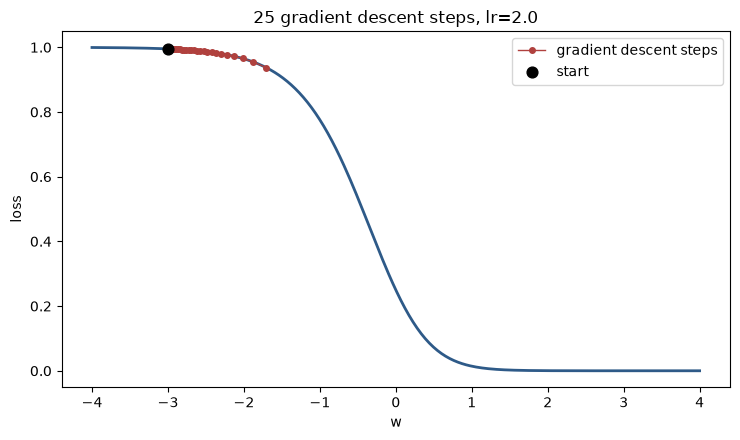

final w: -1.7062  final loss: 0.937198


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# A toy 1-parameter model: predict a fixed target from a fixed input, varying only w.
x_fixed, target = 2.0, 1.0

def loss_at(w):
    a = sigmoid(w * x_fixed)
    return (a - target) ** 2

def grad_at(w):
    a = sigmoid(w * x_fixed)
    da_dz = a * (1 - a)
    return 2 * (a - target) * da_dz * x_fixed

w = -3.0          # start far from the optimum, deliberately
lr = 2.0
trajectory = [w]
for step in range(25):
    w = w - lr * grad_at(w)
    trajectory.append(w)

w_range = np.linspace(-4, 4, 300)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(w_range, [loss_at(wi) for wi in w_range], color='#2E5A88', linewidth=2, zorder=1)
traj_losses = [loss_at(wi) for wi in trajectory]
ax.plot(trajectory, traj_losses, 'o-', color='#B0413E', markersize=4, linewidth=1, zorder=2,
        label='gradient descent steps')
ax.scatter([trajectory[0]], [traj_losses[0]], color='black', s=60, zorder=3, label='start')
ax.set_xlabel('w'); ax.set_ylabel('loss'); ax.legend()
ax.set_title(f'{len(trajectory)-1} gradient descent steps, lr={lr}')
plt.tight_layout()
plt.show()

print("final w:", round(trajectory[-1], 4), " final loss:", round(traj_losses[-1], 6))

Try changing `lr` above to `0.1` (slow crawl) or `15` (overshoots, may even
diverge) and re-run — the learning rate is the single most important knob in
this whole chapter.

## Part 2 — Assembling the full training loop

Training a network is just this loop, repeated:

1. **Forward pass** — compute predictions (Chapter 3).
2. **Loss** — score how wrong they are (Chapter 4).
3. **Backward pass** — compute every weight's gradient (Chapter 5).
4. **Update** — nudge every weight against its gradient (Part 1, above).

In [2]:
def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(float)

def forward(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)
    return Z1, A1, Z2, A2

def bce_loss(A2, y):
    y = y.reshape(A2.shape)
    eps = 1e-12
    p = np.clip(A2, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def backward(X, y, Z1, A1, Z2, A2, W2):
    n = X.shape[0]
    y = y.reshape(A2.shape)
    dZ2 = (A2 - y) / n
    dW2 = A1.T @ dZ2
    db2 = dZ2.sum(axis=0)
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_deriv(Z1)
    dW1 = X.T @ dZ1
    db1 = dZ1.sum(axis=0)
    return dW1, db1, dW2, db2

def train(X, y, n_hidden, lr, epochs, seed=0):
    rng = np.random.default_rng(seed)
    n_in = X.shape[1]
    W1 = rng.normal(scale=1.0, size=(n_in, n_hidden))
    b1 = np.zeros(n_hidden)
    W2 = rng.normal(scale=1.0, size=(n_hidden, 1))
    b2 = np.zeros(1)

    losses = []
    for epoch in range(epochs):
        Z1, A1, Z2, A2 = forward(X, W1, b1, W2, b2)
        losses.append(bce_loss(A2, y))
        dW1, db1, dW2, db2 = backward(X, y, Z1, A1, Z2, A2, W2)
        W1 -= lr * dW1; b1 -= lr * db1
        W2 -= lr * dW2; b2 -= lr * db2
    return W1, b1, W2, b2, losses

## Part 3 — Training on OR: a single neuron is enough

Before trying the full 2-layer network, prove the training loop works at all by
training the *simplest* possible model — one neuron, no hidden layer — on the
linearly separable OR gate from Chapter 1.

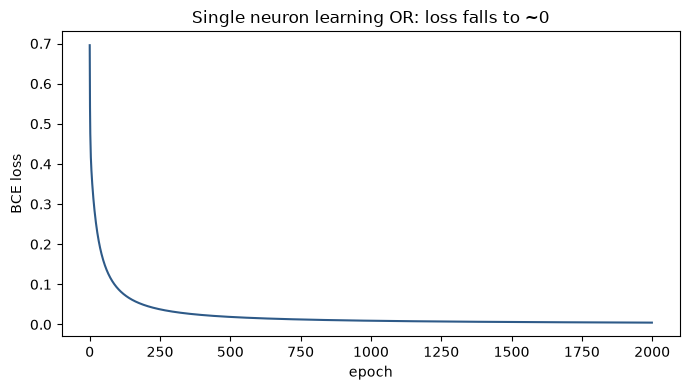

final predictions: [0.0102 0.9959 0.9959 1.    ]
targets:           [0. 1. 1. 1.]


In [3]:
def train_single_neuron(X, y, lr, epochs, seed=0):
    rng = np.random.default_rng(seed)
    w = rng.normal(scale=1.0, size=X.shape[1])
    b = 0.0
    losses = []
    for epoch in range(epochs):
        z = X @ w + b
        a = sigmoid(z)
        losses.append(bce_loss(a, y))
        n = X.shape[0]
        dz = (a - y) / n
        dw = X.T @ dz
        db = dz.sum()
        w -= lr * dw
        b -= lr * db
    return w, b, losses

X_or = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_or = np.array([0, 1, 1, 1], dtype=float)

w_or, b_or, losses_or = train_single_neuron(X_or, y_or, lr=1.0, epochs=2000)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(losses_or, color='#2E5A88')
ax.set_xlabel('epoch'); ax.set_ylabel('BCE loss')
ax.set_title('Single neuron learning OR: loss falls to ~0')
plt.tight_layout()
plt.show()

final_preds = sigmoid(X_or @ w_or + b_or)
print("final predictions:", np.round(final_preds, 4))
print("targets:          ", y_or)

## Part 4 — Training on XOR: the same neuron fails

Now the punchline this whole series has been building toward. XOR is **not**
linearly separable — no single straight line divides the two classes. Watch the
identical training loop hit a wall.

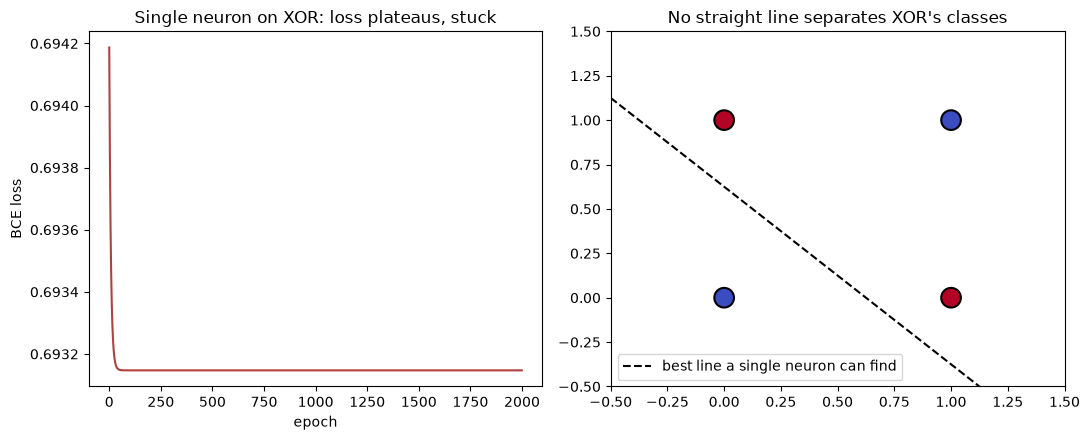

final predictions: [0.5 0.5 0.5 0.5]
targets:           [0. 1. 1. 0.]
final loss: 0.6931  (never gets near 0, unlike OR)


In [4]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0], dtype=float)

w_xor, b_xor, losses_xor = train_single_neuron(X_xor, y_xor, lr=1.0, epochs=2000)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(losses_xor, color='#B0413E')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('BCE loss')
axes[0].set_title('Single neuron on XOR: loss plateaus, stuck')

xs = np.linspace(-0.5, 1.5, 50)
axes[1].scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor, cmap='coolwarm', s=200,
                edgecolors='black', linewidths=1.5, zorder=3)
if w_xor[1] != 0:
    ys = -(w_xor[0] * xs + b_xor) / w_xor[1]
    axes[1].plot(xs, ys, 'k--', label='best line a single neuron can find')
axes[1].set_xlim(-0.5, 1.5); axes[1].set_ylim(-0.5, 1.5)
axes[1].set_title('No straight line separates XOR\'s classes')
axes[1].legend(loc='lower left')
plt.tight_layout()
plt.show()

final_preds_xor = sigmoid(X_xor @ w_xor + b_xor)
print("final predictions:", np.round(final_preds_xor, 4))
print("targets:          ", y_xor)
print("final loss:", round(losses_xor[-1], 4), " (never gets near 0, unlike OR)")

This is the historical crisis that (temporarily) killed neural network research
in the 1970s: Minsky & Papert proved a single neuron (a "perceptron") provably
cannot solve XOR. The fix isn't a smarter neuron — it's *more than one*, arranged
in a hidden layer, exactly like the 2-layer network we've been building since
Chapter 3.

## Recap

Gradient descent turns "the gradient points uphill" into "step downhill,
repeatedly." The full training loop — forward, loss, backward, update — is
mechanical and doesn't care how big the network is. What *does* matter is
whether the network has enough capacity to represent the answer at all: a
single neuron fundamentally cannot separate XOR, no matter how long you train
it or how you tune the learning rate.

**Next:** [Chapter 7 — Building the Full Network From Scratch](07_building_the_full_network.ipynb),
where the 2-layer network finally solves XOR.